In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

def rdd_plot(data, outcome_variable, running_variable, cutoff, fuzzy=False, order=1, bandwidth=None, plot_type='scatter'):
    """
    Plot and estimate Regression Discontinuity Design (RDD) with sharp or fuzzy setting.

    Parameters:
    - data: pandas DataFrame
    - outcome_variable: str, name of outcome variable
    - running_variable: str, name of running variable (forcing variable)
    - cutoff: float, cutoff value for treatment
    - fuzzy: bool, if True, fuzzy RDD
    - order: int, polynomial order (1, 2, 3, or 4)
    - bandwidth: float or None, range around cutoff to use
    - plot_type: 'scatter' or 'line'
    """

    if bandwidth is None:
        bandwidth = np.std(data[running_variable]) * 0.5  # automatic bandwidth

    # Keep data within the bandwidth
    data_trimmed = data[(data[running_variable] >= cutoff - bandwidth) & 
                        (data[running_variable] <= cutoff + bandwidth)].copy()

    # Create treatment variable
    data_trimmed['treated'] = (data_trimmed[running_variable] >= cutoff).astype(int)

    # Polynomial terms
    for i in range(2, order+1):
        data_trimmed[f'{running_variable}^{i}'] = data_trimmed[running_variable] ** i

    # Define model variables
    predictors = [running_variable] + [f'{running_variable}^{i}' for i in range(2, order+1)] + ['treated']
    X = sm.add_constant(data_trimmed[predictors])
    y = data_trimmed[outcome_variable]

    # Fit model
    model = sm.OLS(y, X).fit()

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 5))

    # Scatter plot by side of cutoff
    left = data_trimmed[data_trimmed[running_variable] < cutoff]
    right = data_trimmed[data_trimmed[running_variable] >= cutoff]

    ax.scatter(left[running_variable], left[outcome_variable], color='royalblue', alpha=0.6, label='Left of cutoff')
    ax.scatter(right[running_variable], right[outcome_variable], color='darkred', alpha=0.6, label='Right of cutoff')

    # Lines for fitted values
    x_vals = np.linspace(data_trimmed[running_variable].min(), data_trimmed[running_variable].max(), 300)
    df_pred = pd.DataFrame({running_variable: x_vals})
    for i in range(2, order+1):
        df_pred[f'{running_variable}^{i}'] = x_vals ** i
    df_pred['treated'] = (x_vals >= cutoff).astype(int)
    X_pred = sm.add_constant(df_pred[predictors])
    y_pred = model.predict(X_pred)
    ax.plot(x_vals[x_vals < cutoff], y_pred[x_vals < cutoff], color='navy', linewidth=2.5, label='Fit (Left)')
    ax.plot(x_vals[x_vals >= cutoff], y_pred[x_vals >= cutoff], color='darkorange', linewidth=2.5, label='Fit (Right)')

    ax.axvline(cutoff, color='black', linestyle='--', linewidth=1.5, label='Cutoff')
    ax.set_xlabel(running_variable)
    ax.set_ylabel(outcome_variable)
    ax.set_title("Regression Discontinuity Plot")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Return regression summary
    return model.summary()


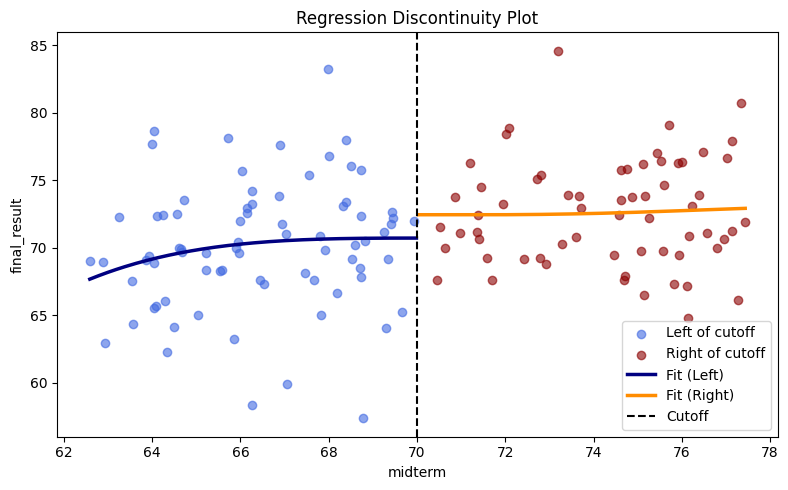

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           final_result   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     2.755
Date:                Fri, 02 May 2025   Prob (F-statistic):             0.0211
Time:                        17:43:32   Log-Likelihood:                -399.97
No. Observations:                 139   AIC:                             811.9
Df Residuals:                     133   BIC:                             829.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -9050.0992   3.89e+04     -0.232      0.817   -8.61e+04     6.8e+04
midterm      499.0675   2230.072      0.224      0.823   -3911.928    4910.063
midterm^2    -10.2262     47.830     -0.214      0.831    -104.833      84.380
midterm^3      0.0930      0.455      0.204      0.839      -0.808       0.994
midterm^4     -0.0003      0.002     -0.195      0.846      -0.004       0.003
treated        1.7282      2.258      0.765      0.445      -2.738       6.194
==============================================================================
Omnibus:                        2.777   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.249   Jarque-Bera (JB):                2.833
Skew:                          -0.004   Prob(JB):                        0.243
Kurtosis:                       3.699   Cond. No.                     2.65e+12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.65e+12. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [19]:
# Generate synthetic student data
import numpy as np
import pandas as pd

# Generate synthetic student data
np.random.seed(42)

# Simulate midterm scores (between 50 and 100)
midterm_scores = np.random.uniform(50, 100, 500)

# Simulate final results with some noise (based on midterm scores)
final_results = 50 + 0.3 * midterm_scores + np.random.normal(0, 5, 500)

# Scholarship based on midterm scores (fuzzy RDD, with a cutoff at 70)
scholarship = (midterm_scores >= 70).astype(int)

# Create a DataFrame
data_large = pd.DataFrame({
    'midterm': midterm_scores,
    'final_result': final_results,
    'scholarship': scholarship
})

# Call the rdd_plot function
rdd_plot(
    data=data_large,
    outcome_variable='final_result',  # Outcome variable
    running_variable='midterm',       # Running variable
    cutoff=70,                       # Cutoff for RDD
    fuzzy=True,                      # Fuzzy RDD
    order=4,                         # Polynomial order (from 1 to 4)
    plot_type='line'              # Use 'scatter' or 'line'
)